## **Projet de classification d'image de cellules afin de détecter le parasite de la Malaria** ##

In [58]:
import numpy as np 
import matplotlib.pyplot as plt 
from PIL import Image
import os
%reload_ext autoreload
%autoreload 2
import Partie_1_Pre_Traitement as pre_traitement
import Partie_2_MLP as mlp
import Partie_3_Evaluation as eval

### 1. Chargement du jeu de donnée ###

In [59]:
data, target = mlp.load_images(
    "Uninfected",
    "Parasitized"
)

data = np.asarray(data)
target = np.asarray(target)

print(data)
print(data.shape)
print(data.min())
print(data.max())
print(data.mean())

[[-0.17836037 -0.17836037 -0.17836037 ... -0.17836037 -0.17836037
  -0.17836037]
 [-0.27239215  0.869243   -0.09941718 ... -0.27239215 -0.27239215
  -0.27239215]
 [-2.200845   -2.200845   -2.200845   ... -2.200845   -2.200845
  -2.200845  ]
 ...
 [-1.1849682  -1.1849682  -1.1849682  ... -1.1849682  -1.1849682
  -1.1849682 ]
 [-1.2570709  -1.2570709  -1.2570709  ... -1.1207205  -1.2570709
  -1.2570709 ]
 [-0.6741721  -0.6741721  -0.6741721  ... -0.6741721  -0.6741721
  -0.6741721 ]]
(2000, 256)
-2.836488
15.925237
2.2053719e-09


### 2. Test du modèle simple ###

In [60]:
modele_simple = mlp.cross_validation(data, target, mlp.mlp_fit, mlp.predict, n_folds=5, learning_rate=0.01)
mlp.save_model(modele_simple, "modele_simple.pkl")


===== Fold 1 =====
Accuracy: 0.6600

===== Fold 2 =====
Accuracy: 0.6350

===== Fold 3 =====
Accuracy: 0.6300

===== Fold 4 =====
Accuracy: 0.6500

===== Fold 5 =====
Accuracy: 0.6350

Accuracy moyenne: 0.6420


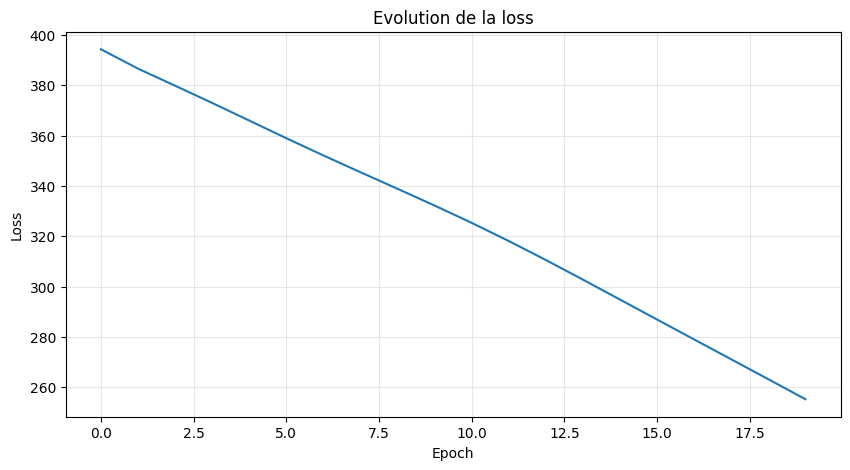

In [61]:
mlp.plot_losses(modele_simple['losses'])

### 3. Test du modèle ReLu ###

In [62]:
modele_relu = mlp.cross_validation(data, target, mlp.mlp_fit_relu, mlp.predict_relu, n_folds=5, learning_rate=0.01, n_epochs=4)
mlp.save_model(modele_relu, "modele_relu.pkl")


===== Fold 1 =====
Accuracy: 0.6950

===== Fold 2 =====
Accuracy: 0.6400

===== Fold 3 =====
Accuracy: 0.6400

===== Fold 4 =====
Accuracy: 0.6350

===== Fold 5 =====
Accuracy: 0.6650

Accuracy moyenne: 0.6550


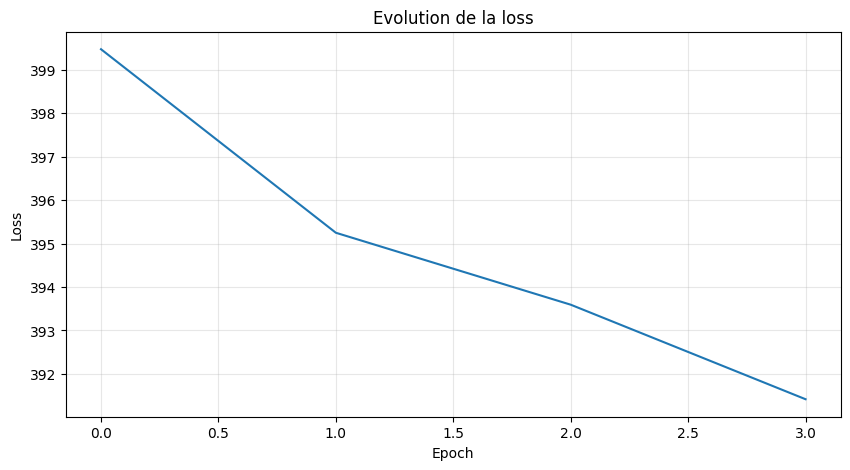

In [63]:
mlp.plot_losses(modele_relu['losses'])

### 4. Test du modèle avec Binary Cross Entropy ###

In [66]:
modele_bce = mlp.cross_validation(data, target, mlp.mlp_fit_bce, mlp.predict_relu, n_folds=5, learning_rate=0.01, n_epochs=11)
mlp.save_model(modele_bce, "modele_bce.pkl")


===== Fold 1 =====
Accuracy: 0.6425

===== Fold 2 =====
Accuracy: 0.6325

===== Fold 3 =====
Accuracy: 0.6825

===== Fold 4 =====
Accuracy: 0.6450

===== Fold 5 =====
Accuracy: 0.6250

Accuracy moyenne: 0.6455


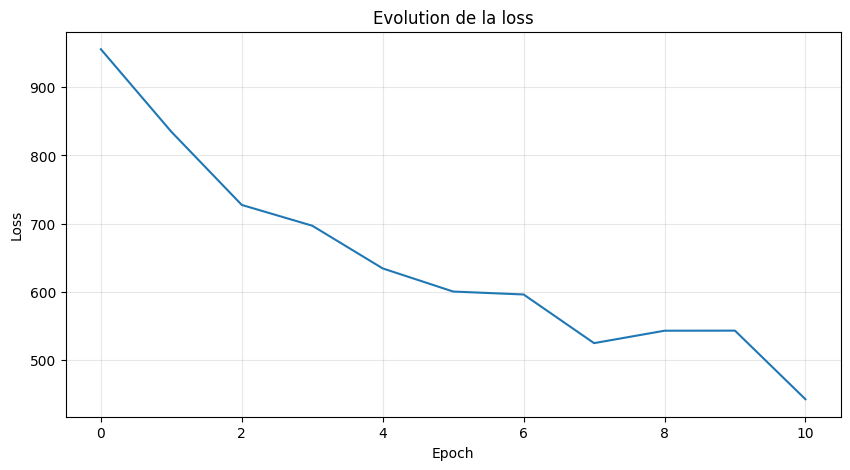

In [67]:
mlp.plot_losses(modele_bce['losses'])

### 5. Test du modèle avec Dropout ###

In [68]:
modele_dropout = mlp.cross_validation(data, target, mlp.mlp_fit_dropout, mlp.predict_dropout, n_folds=5, learning_rate=0.01)
mlp.save_model(modele_dropout, "modele_dropout.pkl")


===== Fold 1 =====
Accuracy: 0.6025

===== Fold 2 =====
Accuracy: 0.5700

===== Fold 3 =====
Accuracy: 0.5750

===== Fold 4 =====
Accuracy: 0.6000

===== Fold 5 =====
Accuracy: 0.5800

Accuracy moyenne: 0.5855


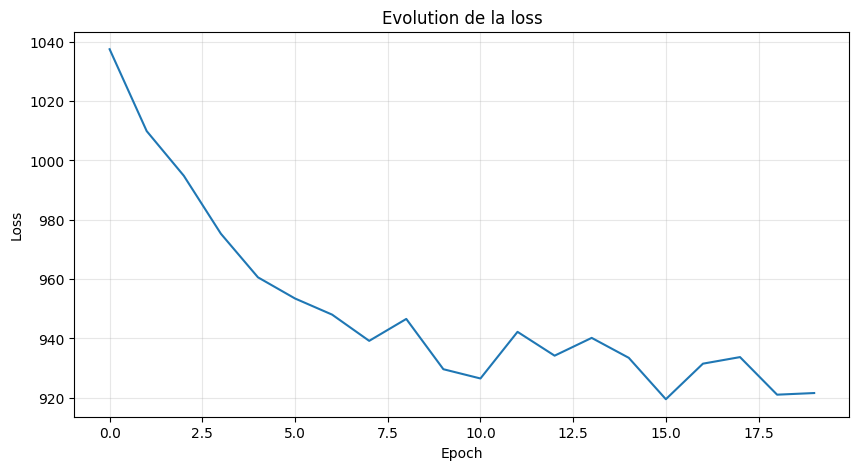

In [69]:
mlp.plot_losses(modele_dropout['losses'])

## 6. Test du modèle avec Mini Batch Gradient ##

In [70]:
modele_mini_batch = mlp.cross_validation(data, target, mlp.mlp_fit_minibatch, mlp.predict_relu, n_folds=5, learning_rate=0.01, n_epochs=100)


===== Fold 1 =====
Accuracy: 0.7050

===== Fold 2 =====
Accuracy: 0.6575

===== Fold 3 =====
Accuracy: 0.6525

===== Fold 4 =====
Accuracy: 0.6425

===== Fold 5 =====
Accuracy: 0.6525

Accuracy moyenne: 0.6620


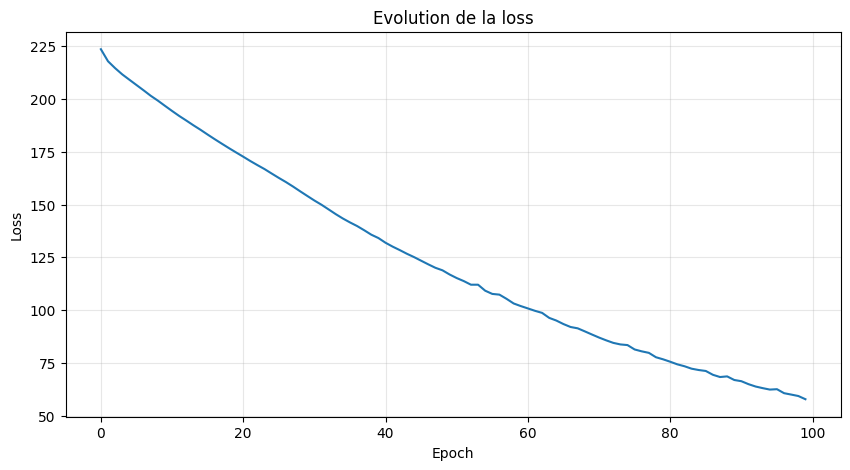

In [47]:
mlp.plot_losses(modele_mini_batch['losses'])